# UCB1 — Upper Confidence Bound Bandit

## Learning Objectives

1. **Formulate** the multi-armed bandit (MAB) problem and define cumulative regret
2. **Derive** the UCB1 index: $\bar{x}_i + \sqrt{2 \ln t / n_i}$ from Hoeffding's inequality
3. **State** the $O(\ln T)$ regret bound and its interpretation
4. **Compare** UCB1 to $\varepsilon$-greedy on regret and sample complexity
5. **Implement** UCB1 and simulate on a Bernoulli bandit


## Problem Statement

### Multi-Armed Bandit

At each round $t = 1, \ldots, T$: choose one arm $i \in \{1, \ldots, K\}$; receive reward $r_t \sim P_i$ (unknown). Goal: maximise total reward, equivalently minimise:
$$R(T) = T \mu^* - \sum_{t=1}^T \mathbb{E}[r_t]$$
where $\mu^* = \max_i \mu_i$ and $\mu_i = \mathbb{E}[P_i]$.

### Explore vs Exploit

- **Exploit:** Pull the arm with highest empirical mean $\bar{x}_i$ — ignores uncertainty
- **Explore:** Try unknown arms — necessary to discover the best arm

**$\varepsilon$-greedy:** With probability $\varepsilon$ explore (random arm), otherwise exploit. Simple but $O(T^{2/3})$ regret.

**UCB1:** Use the principle of **optimism in the face of uncertainty** — add a confidence bonus to empirical means.


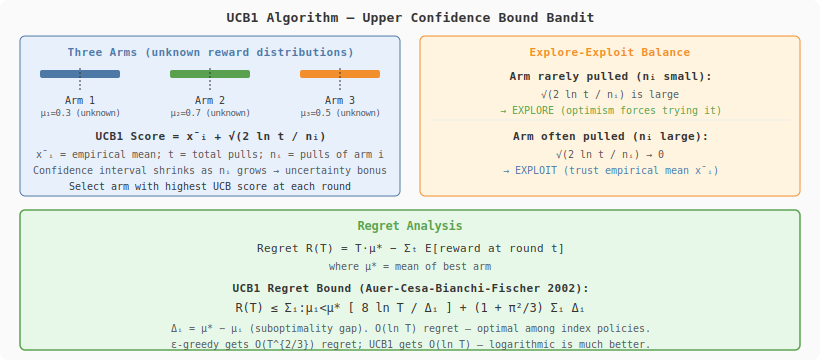

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="820" height="360" font-family="monospace" font-size="12">
  <rect width="820" height="360" fill="#fafafa" rx="8"/>
  <defs><marker id="arr" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto"><polygon points="0 0,8 3,0 6" fill="#999"/></marker></defs>
  <text x="410" y="22" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">UCB1 Algorithm — Upper Confidence Bound Bandit</text>

  <!-- Arm distributions -->
  <rect x="20" y="36" width="380" height="160" rx="5" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="210" y="56" text-anchor="middle" fill="#4e79a7" font-size="11" font-weight="bold">Three Arms (unknown reward distributions)</text>
  <!-- Arm 1 -->
  <rect x="40" y="70" width="80" height="8" rx="2" fill="#4e79a7"/>
  <line x1="80" y1="68" x2="80" y2="90" stroke="#333" stroke-width="1" stroke-dasharray="2,2"/>
  <text x="80" y="104" text-anchor="middle" fill="#333" font-size="10">Arm 1</text>
  <text x="80" y="116" text-anchor="middle" fill="#555" font-size="9">μ₁=0.3 (unknown)</text>
  <!-- Arm 2 -->
  <rect x="170" y="70" width="80" height="8" rx="2" fill="#59a14f"/>
  <line x1="210" y1="68" x2="210" y2="90" stroke="#333" stroke-width="1" stroke-dasharray="2,2"/>
  <text x="210" y="104" text-anchor="middle" fill="#333" font-size="10">Arm 2</text>
  <text x="210" y="116" text-anchor="middle" fill="#555" font-size="9">μ₂=0.7 (unknown)</text>
  <!-- Arm 3 -->
  <rect x="300" y="70" width="80" height="8" rx="2" fill="#f28e2b"/>
  <line x1="340" y1="68" x2="340" y2="90" stroke="#333" stroke-width="1" stroke-dasharray="2,2"/>
  <text x="340" y="104" text-anchor="middle" fill="#333" font-size="10">Arm 3</text>
  <text x="340" y="116" text-anchor="middle" fill="#555" font-size="9">μ₃=0.5 (unknown)</text>

  <!-- UCB scores -->
  <text x="210" y="140" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">UCB1 Score = x̄ᵢ + √(2 ln t / nᵢ)</text>
  <text x="210" y="158" text-anchor="middle" fill="#555" font-size="10">x̄ᵢ = empirical mean;  t = total pulls;  nᵢ = pulls of arm i</text>
  <text x="210" y="174" text-anchor="middle" fill="#555" font-size="10">Confidence interval shrinks as nᵢ grows → uncertainty bonus</text>
  <text x="210" y="190" text-anchor="middle" fill="#333" font-size="10">Select arm with highest UCB score at each round</text>

  <!-- Exploration vs exploitation -->
  <rect x="420" y="36" width="380" height="160" rx="5" fill="#fff4e0" stroke="#f28e2b"/>
  <text x="610" y="56" text-anchor="middle" fill="#f28e2b" font-size="11" font-weight="bold">Explore-Exploit Balance</text>
  <!-- small n: large bonus -->
  <text x="610" y="80" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">Arm rarely pulled (nᵢ small):</text>
  <text x="610" y="98" text-anchor="middle" fill="#555" font-size="10">√(2 ln t / nᵢ) is large</text>
  <text x="610" y="114" text-anchor="middle" fill="#59a14f" font-size="10">→ EXPLORE (optimism forces trying it)</text>
  <line x1="430" y1="120" x2="790" y2="120" stroke="#eee" stroke-width="1"/>
  <text x="610" y="140" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">Arm often pulled (nᵢ large):</text>
  <text x="610" y="158" text-anchor="middle" fill="#555" font-size="10">√(2 ln t / nᵢ) → 0</text>
  <text x="610" y="174" text-anchor="middle" fill="#4e79a7" font-size="10">→ EXPLOIT (trust empirical mean x̄ᵢ)</text>

  <!-- Regret bound -->
  <rect x="20" y="210" width="780" height="140" rx="5" fill="#e8f8e8" stroke="#59a14f" stroke-width="1.5"/>
  <text x="410" y="230" text-anchor="middle" fill="#59a14f" font-size="12" font-weight="bold">Regret Analysis</text>
  <text x="410" y="252" text-anchor="middle" fill="#333" font-size="11">Regret R(T) = T·μ* − Σₜ E[reward at round t]</text>
  <text x="410" y="270" text-anchor="middle" fill="#555" font-size="10">where μ* = mean of best arm</text>
  <text x="410" y="292" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">UCB1 Regret Bound (Auer-Cesa-Bianchi-Fischer 2002):</text>
  <text x="410" y="312" text-anchor="middle" fill="#333" font-size="12">R(T) ≤ Σᵢ:μᵢ&lt;μ* [ 8 ln T / Δᵢ ]  + (1 + π²/3) Σᵢ Δᵢ</text>
  <text x="410" y="332" text-anchor="middle" fill="#555" font-size="10">Δᵢ = μ* − μᵢ (suboptimality gap). O(ln T) regret — optimal among index policies.</text>
  <text x="410" y="348" text-anchor="middle" fill="#555" font-size="10">ε-greedy gets O(T^{2/3}) regret; UCB1 gets O(ln T) — logarithmic is much better.</text>
</svg>
'''
display(SVG(svg))


## Derivation

### Hoeffding's Inequality

For i.i.d. rewards $r_1, \ldots, r_n \in [0,1]$ with mean $\mu$:
$$\Pr\left[\bar{r} - \mu < -\epsilon\right] \leq e^{-2n\epsilon^2}$$

Setting $e^{-2n\epsilon^2} = 1/t^4$ (small probability) gives $\epsilon = \sqrt{2\ln t / n}$.

So with high probability: $\mu_i \leq \bar{x}_i + \sqrt{2\ln t / n_i}$ — the **upper confidence bound** (UCB).

### UCB1 Index

$$\text{UCB}_i(t) = \bar{x}_i + \sqrt{\frac{2 \ln t}{n_i}}$$

Select arm $i_t = \arg\max_i \text{UCB}_i(t)$.

**Intuition:** If arm $i$ is rarely pulled ($n_i$ small) → bonus is large → forced exploration. If $n_i$ is large → bonus shrinks → rely on empirical mean.

### Regret Bound

**Theorem (Auer et al. 2002):** For Bernoulli (or any [0,1]-bounded) rewards:
$$R(T) \leq \sum_{i: \mu_i < \mu^*} \left[\frac{8 \ln T}{\Delta_i} + \left(1 + \frac{\pi^2}{3}\right) \Delta_i\right]$$
where $\Delta_i = \mu^* - \mu_i$ is the suboptimality gap.

**Key facts:**
- Suboptimal arm $i$ is pulled at most $\sim 8\ln T / \Delta_i^2$ times
- Total regret = $O\!\left(\frac{K \ln T}{\Delta_{\min}}\right)$ where $\Delta_{\min} = \min_i \Delta_i$
- Lower bound (Lai-Robbins 1985): any algorithm satisfying $R(T) = o(T^\alpha)$ must have $R(T) \geq \sum_i \frac{\ln T}{\text{KL}(\mu_i, \mu^*)}$ → UCB1 is asymptotically optimal


## Algorithm Steps

1. **Initialise:** pull each arm once; update counts and means
2. **For** $t = K+1, \ldots, T$:
   - Compute $\text{UCB}_i = \bar{x}_i + \sqrt{2\ln t / n_i}$ for each arm $i$
   - Pull arm $i^* = \arg\max_i \text{UCB}_i$
   - Observe reward $r$; update: $\bar{x}_{i^*} \leftarrow \frac{(n_{i^*}-1)\bar{x}_{i^*} + r}{n_{i^*}}$, $n_{i^*} \leftarrow n_{i^*} + 1$


In [2]:
import numpy as np


class UCB1:
    """
    UCB1 algorithm for the stochastic multi-armed bandit problem.

    Score: UCB1ᵢ = x̄ᵢ + √(2 ln t / nᵢ)

    Inputs
    ------
    n_arms : int — number of bandit arms
    """
    def __init__(self, n_arms):
        self.n_arms = n_arms
        self.counts  = np.zeros(n_arms, dtype=int)   # nᵢ: pulls per arm
        self.values  = np.zeros(n_arms)               # x̄ᵢ: empirical mean per arm
        self.t       = 0                              # total rounds

    def select(self):
        """Select arm: return index of arm with highest UCB score."""
        self.t += 1
        # Exploration phase: pull each arm once
        for i in range(self.n_arms):
            if self.counts[i] == 0:
                return i
        # UCB phase
        ucb = self.values + np.sqrt(2 * np.log(self.t) / self.counts)
        return int(np.argmax(ucb))

    def update(self, arm, reward):
        """Update empirical mean for pulled arm."""
        self.counts[arm] += 1
        n = self.counts[arm]
        # Incremental mean update
        self.values[arm] += (reward - self.values[arm]) / n

    def ucb_scores(self):
        if self.t == 0 or any(self.counts == 0):
            return np.full(self.n_arms, np.inf)
        return self.values + np.sqrt(2 * np.log(self.t) / self.counts)


class EpsilonGreedy:
    """Baseline: ε-greedy."""
    def __init__(self, n_arms, epsilon=0.1):
        self.n_arms  = n_arms
        self.epsilon = epsilon
        self.counts  = np.zeros(n_arms, dtype=int)
        self.values  = np.zeros(n_arms)

    def select(self):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_arms)
        return int(np.argmax(self.values))

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]


# ── Simulation ─────────────────────────────────────────────────────────────
rng = np.random.default_rng(42)

# True arm reward probabilities (Bernoulli bandit)
true_means = np.array([0.3, 0.7, 0.5, 0.4])
n_arms = len(true_means)
best_arm = int(np.argmax(true_means))
mu_star  = true_means[best_arm]

T = 1000  # rounds

def simulate(agent, true_means, T, seed=0):
    rng_sim = np.random.default_rng(seed)
    rewards = []
    for t in range(T):
        arm = agent.select()
        reward = float(rng_sim.random() < true_means[arm])  # Bernoulli reward
        agent.update(arm, reward)
        rewards.append(reward)
    return np.array(rewards)

ucb   = UCB1(n_arms)
eps   = EpsilonGreedy(n_arms, epsilon=0.1)

r_ucb = simulate(ucb,  true_means, T, seed=1)
r_eps = simulate(eps,  true_means, T, seed=1)

cumulative_regret_ucb = np.cumsum(mu_star - r_ucb)
cumulative_regret_eps = np.cumsum(mu_star - r_eps)

print(f"True means: {true_means}  (best arm {best_arm}, μ*={mu_star})")
print(f"\nAfter {T} rounds:")
print(f"  UCB1 cumulative regret:    {cumulative_regret_ucb[-1]:.2f}")
print(f"  ε-greedy cumulative regret:{cumulative_regret_eps[-1]:.2f}")
print(f"\nUCB1 arm counts: {ucb.counts}")
print(f"UCB1 estimated means: {ucb.values.round(3)}")
print(f"UCB1 final UCB scores: {ucb.ucb_scores().round(4)}")


True means: [0.3 0.7 0.5 0.4]  (best arm 1, μ*=0.7)

After 1000 rounds:
  UCB1 cumulative regret:    80.00
  ε-greedy cumulative regret:36.00

UCB1 arm counts: [ 71 724 115  90]
UCB1 estimated means: [0.38  0.689 0.478 0.433]
UCB1 final UCB scores: [0.8214 0.8274 0.8249 0.8251]
